# Multi Source Pipeline

In [1]:
# import libraries

import requests
import pandas as pd
import numpy as np

In [2]:
# url of coingecko api 

url = "https://api.coingecko.com/api/v3/coins/markets"

In [3]:
# api parameters

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": "false",
    "price_change_percentage": "1h,24h,7d,30d"
}

In [4]:
#  SEND REQUEST TO COINGECKO API

response = requests.get(url, params=params)

print(response.status_code)

200


In [5]:
# convert api response to json

data = response.json()

print("Data Type:", type(data))

# API sends the data back as JSON so we need to send response in json only 

Data Type: <class 'list'>


In [6]:
# check number of records

print("Number of Records:", len(data))

Number of Records: 100


In [7]:
# inspect first cryptocurrency record

data[0]

{'id': 'bitcoin',
 'symbol': 'btc',
 'name': 'Bitcoin',
 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400',
 'current_price': 79507,
 'market_cap': 1596870964625,
 'market_cap_rank': 1,
 'fully_diluted_valuation': 1596880665922,
 'total_volume': 33995433908,
 'high_24h': 79701,
 'low_24h': 77666,
 'price_change_24h': 1056.06,
 'price_change_percentage_24h': 1.36466,
 'market_cap_change_24h': 21465038911,
 'market_cap_change_percentage_24h': 1.36251,
 'circulating_supply': 20081671.0,
 'total_supply': 20081793.0,
 'max_supply': 21000000.0,
 'ath': 126080,
 'ath_change_percentage': -36.9389,
 'ath_date': '2025-10-06T10:57:42.000Z',
 'atl': 67.81,
 'atl_change_percentage': 117151.94284,
 'atl_date': '2013-07-05T16:00:00.000Z',
 'roi': None,
 'last_updated': '2026-09-09T09:15:20.000Z',
 'price_change_percentage_1h_in_currency': 0.5,
 'price_change_percentage_24h_in_currency': 1.36466,
 'price_change_percentage_30d_in_currency': 22.3,
 'price_change_pe

In [8]:
# convert json to data frame

crypto_raw = pd.DataFrame(data)

crypto_raw.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,79507.000000,1596870964625,1,1596880665922,3.399543e+10,79701.000000,...,2025-10-06T10:57:42.000Z,67.810000,1.171519e+05,2013-07-05T16:00:00.000Z,None,2026-09-09T09:15:20.000Z,0.5,1.36466,22.3,2.9
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2511.460000,306564437911,2,306564437911,1.196957e+10,2521.510000,...,2025-08-24T11:21:03.000Z,0.432979,5.799424e+05,2015-10-19T16:00:00.000Z,"{'times': 41.22977864471396, 'currency': 'btc'...",2026-09-09T09:15:20.000Z,0.5,1.26711,31.0,4.3
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999747,183414381146,3,188879961811,5.240008e+10,0.999995,...,2018-07-23T16:00:00.000Z,0.572521,7.462183e+01,2015-03-01T16:00:00.000Z,None,2026-09-09T09:15:20.000Z,0.0,-0.00437,0.0,0.0
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,756.640000,100771991871,4,100771986074,9.933761e+08,757.670000,...,2025-10-13T00:41:24.000Z,0.039818,1.900169e+06,2017-10-18T16:00:00.000Z,None,2026-09-09T09:15:20.000Z,0.4,0.32042,25.4,10.1
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.430000,89903339234,5,143264208173,2.589350e+09,1.450000,...,2025-07-17T19:40:53.000Z,0.002686,5.322538e+04,2014-05-21T16:00:00.000Z,None,2026-09-09T09:15:20.000Z,-0.2,2.92170,38.7,6.9


In [9]:
# check data shape 

crypto_raw.shape

(100, 30)

In [10]:
# check column names

crypto_raw.columns.tolist()

['id',
 'symbol',
 'name',
 'image',
 'current_price',
 'market_cap',
 'market_cap_rank',
 'fully_diluted_valuation',
 'total_volume',
 'high_24h',
 'low_24h',
 'price_change_24h',
 'price_change_percentage_24h',
 'market_cap_change_24h',
 'market_cap_change_percentage_24h',
 'circulating_supply',
 'total_supply',
 'max_supply',
 'ath',
 'ath_change_percentage',
 'ath_date',
 'atl',
 'atl_change_percentage',
 'atl_date',
 'roi',
 'last_updated',
 'price_change_percentage_1h_in_currency',
 'price_change_percentage_24h_in_currency',
 'price_change_percentage_30d_in_currency',
 'price_change_percentage_7d_in_currency']

In [11]:
# initial data set information

crypto_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       100 non-null    object 
 1   symbol                                   100 non-null    object 
 2   name                                     100 non-null    object 
 3   image                                    100 non-null    object 
 4   current_price                            100 non-null    float64
 5   market_cap                               100 non-null    int64  
 6   market_cap_rank                          100 non-null    int64  
 7   fully_diluted_valuation                  100 non-null    int64  
 8   total_volume                             100 non-null    float64
 9   high_24h                                 100 non-null    float64
 10  low_24h                                  100 non-nu

In [12]:
# check missing values

crypto_raw.isnull().sum()

id                                          0
symbol                                      0
name                                        0
image                                       0
current_price                               0
market_cap                                  0
market_cap_rank                             0
fully_diluted_valuation                     0
total_volume                                0
high_24h                                    0
low_24h                                     0
price_change_24h                            1
price_change_percentage_24h                 1
market_cap_change_24h                       1
market_cap_change_percentage_24h            1
circulating_supply                          0
total_supply                                0
max_supply                                 47
ath                                         0
ath_change_percentage                       0
ath_date                                    0
atl                               

In [ ]:
# check duplicate cyptocurrencies

print("Duplicate IDs:", crypto_raw["id"].duplicated().sum())

Duplicate IDs: 0


In [15]:
# Check duplicate symbols

print("Duplicate Symbols:", crypto_raw["symbol"].duplicated().sum())

Duplicate Symbols: 0


In [16]:
# check their data types

crypto_raw.dtypes

id                                          object
symbol                                      object
name                                        object
image                                       object
current_price                              float64
market_cap                                   int64
market_cap_rank                              int64
fully_diluted_valuation                      int64
total_volume                               float64
high_24h                                   float64
low_24h                                    float64
price_change_24h                           float64
price_change_percentage_24h                float64
market_cap_change_24h                      float64
market_cap_change_percentage_24h           float64
circulating_supply                         float64
total_supply                               float64
max_supply                                 float64
ath                                        float64
ath_change_percentage          

In [17]:
# check for nested dictionary values

for column in crypto_raw.columns:
    if crypto_raw[column].apply(lambda x: isinstance(x, dict)).any():
        print(column)

roi


In [ ]:
# check missing values

missing_values = crypto_raw.isnull().sum()

missing_values[missing_values > 0]

price_change_24h                            1
price_change_percentage_24h                 1
market_cap_change_24h                       1
market_cap_change_percentage_24h            1
max_supply                                 47
roi                                        91
price_change_percentage_24h_in_currency     1
dtype: int64

In [19]:
# check numerical summary 

crypto_raw.describe()

,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,market_cap_change_24h,...,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency
count,100.000000,1.000000e+02,100.000000,1.000000e+02,1.000000e+02,100.000000,100.000000,99.000000,99.000000,9.900000e+01,...,1.000000e+02,5.300000e+01,100.000000,100.000000,1.000000e+02,1.000000e+02,100.000000,99.000000,100.00000,100.000000
mean,948.250526,2.743707e+10,49.590000,2.957255e+10,1.413154e+09,950.950086,926.166401,12.330780,1.654299,3.372934e+08,...,1.911892e+13,2.686225e+13,1577.288436,-53.178386,3.142954e+01,1.625901e+05,0.262000,1.654299,45.00000,10.181000
std,7963.959173,1.630987e+11,28.869996,1.634303e+11,6.454020e+09,7983.386251,7779.961062,106.705904,5.967123,2.208731e+09,...,1.143606e+14,1.479812e+14,12619.182421,36.764577,2.002358e+02,1.034120e+06,0.728189,5.967123,188.14834,16.937727
min,0.000002,5.737996e+08,1.000000,5.626809e+08,0.000000e+00,0.000002,0.000002,-21.710739,-7.227900,-6.375323e+08,...,4.325033e+05,1.461249e+07,0.000004,-99.647680,5.636600e-11,0.000000e+00,-2.100000,-7.227900,-17.50000,-7.800000
25%,0.367753,9.990444e+08,24.750000,1.275421e+09,1.614147e+07,0.374242,0.361875,-0.000271,-0.067550,-8.912896e+06,...,5.325767e+08,4.000000e+08,1.027750,-87.562960,4.688420e-02,3.845209e+01,0.000000,-0.067550,0.55000,0.000000
50%,1.000000,1.854089e+09,49.500000,2.566505e+09,8.172999e+07,1.000000,0.999915,0.000496,0.043120,1.067979e+07,...,1.598923e+09,2.100000e+09,2.635000,-62.149660,5.100825e-01,2.996017e+02,0.050000,0.043120,20.25000,5.150000
75%,7.257500,4.240167e+09,74.250000,5.955913e+09,2.403561e+08,7.395000,7.180000,0.036588,2.667385,7.129265e+07,...,1.000000e+10,2.346267e+10,52.640000,-16.197445,9.908043e-01,2.976500e+03,0.500000,2.667385,38.10000,12.225000
max,79507.000000,1.596871e+12,99.000000,1.596881e+12,5.240008e+10,79701.000000,77666.000000,1056.060000,47.979920,2.146504e+10,...,8.982327e+14,9.999900e+14,126080.000000,0.000000,1.447840e+03,9.684751e+06,4.400000,47.979920,1879.80000,105.900000


In [20]:
# unique values

print("Unique IDs:", crypto_raw["id"].nunique())
print("Unique Symbols:", crypto_raw["symbol"].nunique())
print("Unique Names:", crypto_raw["name"].nunique())

Unique IDs: 100
Unique Symbols: 100
Unique Names: 100


In [21]:
# save raw data

crypto_raw.to_csv("../data/raw/crypto_raw.csv",index=False)

print("Raw crypto dataset saved successfully!")

Raw crypto dataset saved successfully!


# Crypto Data Cleaning

In [22]:
# create a cleaning copy


crypto_clean = crypto_raw.copy()

print("Cleaning copy created successfully!")
print("Shape:", crypto_clean.shape)

Cleaning copy created successfully!
Shape: (100, 30)


In [23]:

# remove nested roi column

crypto_clean = crypto_clean.drop(columns=["roi"])

print("ROI column removed.")
print("New shape:", crypto_clean.shape)

ROI column removed.
New shape: (100, 29)


In [25]:
# check invalid crypto prices

negative_prices = (crypto_clean["current_price"] < 0).sum()
zero_prices = (crypto_clean["current_price"] == 0).sum()

print("Negative prices:", negative_prices)
print("Zero prices:", zero_prices)

Negative prices: 0
Zero prices: 0


In [26]:
# remove invalid prices

crypto_clean = crypto_clean[crypto_clean["current_price"] > 0].copy()

print("Shape after price validation:", crypto_clean.shape)

Shape after price validation: (100, 29)


In [ ]:
# convert numeric colums

numeric_columns = [
    "current_price",
    "market_cap",
    "market_cap_rank",
    "fully_diluted_valuation",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_24h",
    "price_change_percentage_24h",
    "market_cap_change_24h",
    "market_cap_change_percentage_24h",
    "circulating_supply",
    "total_supply",
    "max_supply",
    "ath",
    "ath_change_percentage",
    "atl",
    "atl_change_percentage",
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_30d_in_currency",
    "price_change_percentage_7d_in_currency"
]

for column in numeric_columns:
    crypto_clean[column] = pd.to_numeric(
        crypto_clean[column],
        errors="coerce"      # it convert to NaN if data has not applicable,N/A, unknown
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [29]:
# convert data columns

date_columns = [
    "ath_date",
    "atl_date",
    "last_updated"
]

for column in date_columns:
    crypto_clean[column] = pd.to_datetime(
        crypto_clean[column],
        errors="coerce",
        utc=True
    )

print("Date conversion completed.")

Date conversion completed.


In [30]:
crypto_clean[date_columns].dtypes

ath_date        datetime64[ns, UTC]
atl_date        datetime64[ns, UTC]
last_updated    datetime64[ns, UTC]
dtype: object

In [32]:
# handle missing market change values

change_columns = [
    "price_change_24h",
    "price_change_percentage_24h",
    "market_cap_change_24h",
    "market_cap_change_percentage_24h",
    "price_change_percentage_24h_in_currency"
]

for column in change_columns:
    crypto_clean[column] = crypto_clean[column].fillna(
        crypto_clean[column].median()
    )

print("Missing market-change values handled.")

Missing market-change values handled.


In [ ]:

# CHECK MISSING VALUES AFTER CLEANING


missing_after = crypto_clean.isnull().sum()

missing_after[missing_after > 0]

max_supply    47
dtype: int64

In [ ]:

# FINAL DUPLICATE CHECK


print(
    "Duplicate IDs:",
    crypto_clean["id"].duplicated().sum()
)

print(
    "Duplicate Symbols:",
    crypto_clean["symbol"].duplicated().sum()
)

Duplicate IDs: 0
Duplicate Symbols: 0


In [ ]:

#  CLEANED DATASET VALIDATION


print("Shape:", crypto_clean.shape)
print("\nData Types:")
print(crypto_clean.dtypes)

print("\nMissing Values:")
print(crypto_clean.isnull().sum()[crypto_clean.isnull().sum() > 0])

Shape: (100, 29)

Data Types:
id                                                      object
symbol                                                  object
name                                                    object
image                                                   object
current_price                                          float64
market_cap                                               int64
market_cap_rank                                          int64
fully_diluted_valuation                                  int64
total_volume                                           float64
high_24h                                               float64
low_24h                                                float64
price_change_24h                                       float64
price_change_percentage_24h                            float64
market_cap_change_24h                                  float64
market_cap_change_percentage_24h                       float64
circulating_supply       

# Crypto Outlier Analysis

In [ ]:
# SELECT FEATURES FOR OUTLIER ANALYSIS

outlier_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]

print("Columns selected for outlier analysis:")
print(outlier_columns)

Columns selected for outlier analysis:
['current_price', 'market_cap', 'total_volume', 'price_change_percentage_24h']


In [ ]:
# IQR OUTLIER DETECTION FUNCTION


def detect_iqr_outliers(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound

In [ ]:
# APPLY IQR OUTLIER DETECTION

iqr_results = {}

for column in outlier_columns:
    
    outliers, lower_bound, upper_bound = detect_iqr_outliers(
        crypto_clean,
        column
    )
    
    iqr_results[column] = {
        "outlier_count": len(outliers),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

    print(f"\n{column}")
    print("Outliers:", len(outliers))
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


current_price
Outliers: 19
Lower Bound: -9.9668675
Upper Bound: 17.5921205

market_cap
Outliers: 17
Lower Bound: -3862638884.25
Upper Bound: 9101849761.75

total_volume
Outliers: 15
Lower Bound: -320180432.5
Upper Bound: 576677981.5

price_change_percentage_24h
Outliers: 12
Lower Bound: -4.10241375
Upper Bound: 6.70891625


In [ ]:
# IQR OUTLIER SUMMARY


iqr_summary = pd.DataFrame(iqr_results).T

iqr_summary

,outlier_count,lower_bound,upper_bound
current_price,19.0,-9.966867e+00,1.759212e+01
market_cap,17.0,-3.862639e+09,9.101850e+09
total_volume,15.0,-3.201804e+08,5.766780e+08
price_change_percentage_24h,12.0,-4.102414e+00,6.708916e+00


In [ ]:
# INSPECT MARKET CAP OUTLIERS


market_cap_outliers, lower_bound, upper_bound = detect_iqr_outliers(
    crypto_clean,
    "market_cap"
)

market_cap_outliers[
    ["id", "name", "current_price", "market_cap"]
].sort_values(
    "market_cap",
    ascending=False
)

,id,name,current_price,market_cap
0,bitcoin,Bitcoin,79507.000000,1596870964625
1,ethereum,Ethereum,2511.460000,306564437911
2,tether,Tether,0.999747,183414381146
3,binancecoin,BNB,756.640000,100771991871
4,ripple,XRP,1.430000,89903339234
5,usd-coin,USDC,0.999926,74376069108
6,solana,Solana,104.500000,61279702441
7,tron,TRON,0.339142,32202840190
8,figure-heloc,Figure Heloc,1.035000,23075166018
9,zcash,Zcash,1251.600000,21188089482


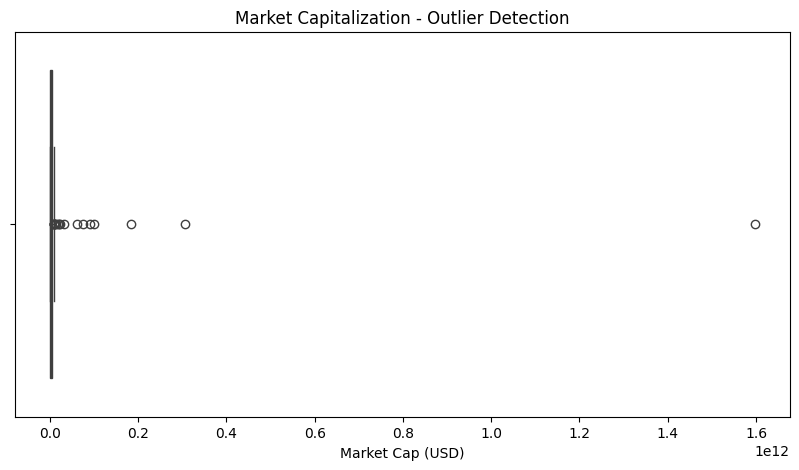

In [ ]:
# BOX PLOT - MARKET CAP


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=crypto_clean["market_cap"]
)

plt.title("Market Capitalization - Outlier Detection")
plt.xlabel("Market Cap (USD)")

plt.show()

In [ ]:
# IMPORT ISOLATION FOREST


from sklearn.ensemble import IsolationForest

In [ ]:
#  PREPARE FEATURES FOR ISOLATION FOREST


isolation_features = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]

crypto_if = crypto_clean[isolation_features].copy()

crypto_if["current_price"] = np.log1p(
    crypto_if["current_price"]
)

crypto_if["market_cap"] = np.log1p(
    crypto_if["market_cap"]
)

crypto_if["total_volume"] = np.log1p(
    crypto_if["total_volume"]
)

crypto_if = crypto_if.replace(
    [np.inf, -np.inf],
    np.nan
)

crypto_if = crypto_if.fillna(
    crypto_if.median()
)

crypto_if.head()

,current_price,market_cap,total_volume,price_change_percentage_24h
0,11.283613,28.099067,24.249492,1.36466
1,7.829018,26.448694,23.205634,1.26711
2,0.693021,25.935014,24.682174,-0.00437
3,6.630208,25.336126,20.716620,0.32042
4,0.887891,25.222001,21.674673,2.92170


In [ ]:

# APPLY ISOLATION FOREST


iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

crypto_if["outlier_prediction"] = iso_forest.fit_predict(
    crypto_if[isolation_features]
)

In [ ]:
# ADD ISOLATION FOREST RESULTS


crypto_clean["isolation_outlier"] = crypto_if[
    "outlier_prediction"
]

crypto_clean["isolation_outlier"].value_counts()

isolation_outlier
 1    95
-1     5
Name: count, dtype: int64

In [ ]:
# INSPECT ISOLATION FOREST OUTLIERS


crypto_clean[
    crypto_clean["isolation_outlier"] == -1
][
    [
        "id",
        "name",
        "current_price",
        "market_cap",
        "total_volume",
        "price_change_percentage_24h"
    ]
]

,id,name,current_price,market_cap,total_volume,price_change_percentage_24h
0,bitcoin,Bitcoin,79507.00,1596870964625,3.399543e+10,1.36466
1,ethereum,Ethereum,2511.46,306564437911,1.196957e+10,1.26711
9,zcash,Zcash,1251.60,21188089482,1.235654e+09,10.28189
67,venice-token,Venice Token,26.70,1278858382,3.109582e+08,47.97992
77,blockchain-capital,Blockchain Capital,106.49,970348700,0.000000e+00,0.25419


In [ ]:
# CREATE OUTLIER FLAG

crypto_clean["is_outlier"] = (
    crypto_clean["isolation_outlier"] == -1
)

crypto_clean["is_outlier"].value_counts()

is_outlier
False    95
True      5
Name: count, dtype: int64

In [ ]:
#  REMOVE TEMPORARY OUTLIER COLUMN

crypto_clean = crypto_clean.drop(
    columns=["isolation_outlier"]
)

crypto_clean.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_date,atl,atl_change_percentage,atl_date,last_updated,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency,is_outlier
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,79507.000000,1596870964625,1,1596880665922,3.399543e+10,79701.000000,...,2025-10-06 10:57:42+00:00,67.810000,1.171519e+05,2013-07-05 16:00:00+00:00,2026-09-09 09:15:20+00:00,0.5,1.36466,22.3,2.9,True
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2511.460000,306564437911,2,306564437911,1.196957e+10,2521.510000,...,2025-08-24 11:21:03+00:00,0.432979,5.799424e+05,2015-10-19 16:00:00+00:00,2026-09-09 09:15:20+00:00,0.5,1.26711,31.0,4.3,True
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999747,183414381146,3,188879961811,5.240008e+10,0.999995,...,2018-07-23 16:00:00+00:00,0.572521,7.462183e+01,2015-03-01 16:00:00+00:00,2026-09-09 09:15:20+00:00,0.0,-0.00437,0.0,0.0,False
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,756.640000,100771991871,4,100771986074,9.933761e+08,757.670000,...,2025-10-13 00:41:24+00:00,0.039818,1.900169e+06,2017-10-18 16:00:00+00:00,2026-09-09 09:15:20+00:00,0.4,0.32042,25.4,10.1,False
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.430000,89903339234,5,143264208173,2.589350e+09,1.450000,...,2025-07-17 19:40:53+00:00,0.002686,5.322538e+04,2014-05-21 16:00:00+00:00,2026-09-09 09:15:20+00:00,-0.2,2.92170,38.7,6.9,False


# CRYPTO FEATURE ENGINEERING

In [ ]:
#  CREATE MARKET CAP CATEGORY

def classify_market_cap(market_cap):
    
    if market_cap >= 10_000_000_000:
        return "Large Cap"
    
    elif market_cap >= 1_000_000_000:
        return "Mid Cap"
    
    else:
        return "Small Cap"


crypto_clean["market_cap_category"] = (
    crypto_clean["market_cap"]
    .apply(classify_market_cap)
)

crypto_clean[
    ["name", "market_cap", "market_cap_category"]
].head(10)

,name,market_cap,market_cap_category
0,Bitcoin,1596870964625,Large Cap
1,Ethereum,306564437911,Large Cap
2,Tether,183414381146,Large Cap
3,BNB,100771991871,Large Cap
4,XRP,89903339234,Large Cap
5,USDC,74376069108,Large Cap
6,Solana,61279702441,Large Cap
7,TRON,32202840190,Large Cap
8,Figure Heloc,23075166018,Large Cap
9,Zcash,21188089482,Large Cap


In [ ]:

#  CHECK MARKET CAP CATEGORIES


crypto_clean["market_cap_category"].value_counts()

market_cap_category
Mid Cap      61
Small Cap    26
Large Cap    13
Name: count, dtype: int64

In [ ]:

# CREATE VOLATILITY SCORE


volatility_columns = [
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_7d_in_currency",
    "price_change_percentage_30d_in_currency"
]

crypto_clean["volatility_score"] = (
    crypto_clean[volatility_columns]
    .abs()
    .mean(axis=1)
)

crypto_clean[
    ["name", "volatility_score"]
].head(10)

,name,volatility_score
0,Bitcoin,6.766165
1,Ethereum,9.266777
2,Tether,0.001092
3,BNB,9.055105
4,XRP,12.180425
5,USDC,0.001015
6,Solana,10.723470
7,TRON,2.095477
8,Figure Heloc,0.935780
9,Zcash,50.995473


In [ ]:

#  CREATE VOLATILITY CATEGORY


def classify_volatility(score):
    
    if score >= 20:
        return "High"
    
    elif score >= 5:
        return "Medium"
    
    else:
        return "Low"


crypto_clean["volatility_category"] = (
    crypto_clean["volatility_score"]
    .apply(classify_volatility)
)

crypto_clean[
    [
        "name",
        "volatility_score",
        "volatility_category"
    ]
].head(10)

,name,volatility_score,volatility_category
0,Bitcoin,6.766165,Medium
1,Ethereum,9.266777,Medium
2,Tether,0.001092,Low
3,BNB,9.055105,Medium
4,XRP,12.180425,Medium
5,USDC,0.001015,Low
6,Solana,10.723470,Medium
7,TRON,2.095477,Low
8,Figure Heloc,0.935780,Low
9,Zcash,50.995473,High


In [ ]:

#  CREATE SUPPLY RATIO


crypto_clean["supply_ratio"] = (
    crypto_clean["circulating_supply"] /
    crypto_clean["total_supply"]
)

crypto_clean[
    [
        "name",
        "circulating_supply",
        "total_supply",
        "supply_ratio"
    ]
].head(10)

,name,circulating_supply,total_supply,supply_ratio
0,Bitcoin,2.008167e+07,2.008179e+07,0.999994
1,Ethereum,1.220326e+08,1.220326e+08,1.000000
2,Tether,1.834602e+11,1.889271e+11,0.971063
3,BNB,1.331614e+08,1.331614e+08,1.000000
4,XRP,6.274450e+10,9.998563e+10,0.627535
5,USDC,7.438140e+10,7.440293e+10,0.999711
6,Solana,5.862506e+08,6.337369e+08,0.925069
7,TRON,9.494072e+10,9.494205e+10,0.999986
8,Figure Heloc,2.229061e+10,2.229061e+10,1.000000
9,Zcash,1.692187e+07,1.692265e+07,0.999954


In [ ]:

#  VALIDATE SUPPLY RATIO


print(
    "Supply ratios below 0:",
    (crypto_clean["supply_ratio"] < 0).sum()
)

print(
    "Supply ratios above 1:",
    (crypto_clean["supply_ratio"] > 1).sum()
)

print(
    "Missing supply ratios:",
    crypto_clean["supply_ratio"].isnull().sum()
)

Supply ratios below 0: 0
Supply ratios above 1: 7
Missing supply ratios: 0


In [ ]:
#  CREATE 24H PRICE CHANGE CATEGORY


def classify_price_change(change):
    
    if change < -5:
        return "Strong Loss"
    
    elif change < 0:
        return "Loss"
    
    elif change == 0:
        return "No Change"
    
    elif change <= 5:
        return "Gain"
    
    else:
        return "Strong Gain"


crypto_clean["price_change_category"] = (
    crypto_clean["price_change_percentage_24h"]
    .apply(classify_price_change)
)

crypto_clean[
    [
        "name",
        "price_change_percentage_24h",
        "price_change_category"
    ]
].head(10)

,name,price_change_percentage_24h,price_change_category
0,Bitcoin,1.36466,Gain
1,Ethereum,1.26711,Gain
2,Tether,-0.00437,Loss
3,BNB,0.32042,Gain
4,XRP,2.92170,Gain
5,USDC,0.00406,Gain
6,Solana,1.29388,Gain
7,TRON,0.38191,Gain
8,Figure Heloc,0.04312,Gain
9,Zcash,10.28189,Strong Gain


In [ ]:
#  CHECK ENGINEERED FEATURES


engineered_columns = [
    "market_cap_category",
    "volatility_score",
    "volatility_category",
    "supply_ratio",
    "price_change_category"
]

crypto_clean[engineered_columns].head(10)

,market_cap_category,volatility_score,volatility_category,supply_ratio,price_change_category
0,Large Cap,6.766165,Medium,0.999994,Gain
1,Large Cap,9.266777,Medium,1.000000,Gain
2,Large Cap,0.001092,Low,0.971063,Loss
3,Large Cap,9.055105,Medium,1.000000,Gain
4,Large Cap,12.180425,Medium,0.627535,Gain
5,Large Cap,0.001015,Low,0.999711,Gain
6,Large Cap,10.723470,Medium,0.925069,Gain
7,Large Cap,2.095477,Low,0.999986,Gain
8,Large Cap,0.935780,Low,1.000000,Gain
9,Large Cap,50.995473,High,0.999954,Strong Gain


In [ ]:
#  FEATURE ENGINEERING SUMMARY


print("New Features Created:")
print()

for column in engineered_columns:
    print("-", column)

New Features Created:

- market_cap_category
- volatility_score
- volatility_category
- supply_ratio
- price_change_category


In [ ]:
# CHECK FINAL CRYPTO DATASET


print("Shape:", crypto_clean.shape)

print("\nColumns:")
print(crypto_clean.columns.tolist())

print("\nMissing Values:")
print(
    crypto_clean.isnull().sum()[
        crypto_clean.isnull().sum() > 0
    ]
)